In [2]:
import pandas as pd

df = pd.read_csv(r"C:\ShieldNet-AI\data/cic_aligned_training.csv")
df.head()


,Flow Duration,Total Fwd Packets,Total Bwd Packets,Total Length Fwd,Fwd Packet Max,Idle Mean,Label
0,4,2,0,12,6,0.0,Benign
1,1,2,0,12,6,0.0,Benign
2,3,2,0,12,6,0.0,Benign
3,1,2,0,12,6,0.0,Benign
4,609,7,4,484,233,0.0,Benign


In [3]:
df["BinaryLabel"] = (
    df["Label"]
    .str.strip()
    .str.lower()
    .apply(lambda x: "Benign" if x == "benign" else "Attack")
)
df["BinaryLabel"].value_counts()


BinaryLabel
Benign    1977318
Attack     336492
Name: count, dtype: int64

In [4]:
FEATURE_COLUMNS = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Bwd Packets",
    "Total Length Fwd",
    "Fwd Packet Max",
    "Idle Mean"
]

X = df[FEATURE_COLUMNS]
y = df["BinaryLabel"]


In [5]:
import numpy as np

X_log = X.copy()
for col in FEATURE_COLUMNS:
    X_log[col] = np.log1p(X_log[col])


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log1p
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [6]:
# Train–test split (stratified) - This prevents label imbalance issues.

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_log,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
import numpy as np

X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test  = X_test.replace([np.inf, -np.inf], np.nan)

X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

X_test = X_test.dropna()
y_test = y_test.loc[X_test.index]

In [8]:
# Scale features - Fit on train only. 

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [10]:
import joblib
from pathlib import Path

Path("models").mkdir(exist_ok=True)
joblib.dump(scaler, "models/scaler.pkl")


['models/scaler.pkl']

In [9]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

def evaluate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    print("Classification Report:")
    print(classification_report(y_test, y_pred))
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title("Confusion Matrix")
    plt.show()
    
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test)[:, 1]
        roc = roc_auc_score((y_test == "Attack").astype(int), y_prob)
        print("ROC-AUC:", roc)


Classification Report:
              precision    recall  f1-score   support

      Attack       0.37      0.82      0.51     67298
      Benign       0.96      0.76      0.85    395439

    accuracy                           0.77    462737
   macro avg       0.67      0.79      0.68    462737
weighted avg       0.88      0.77      0.80    462737



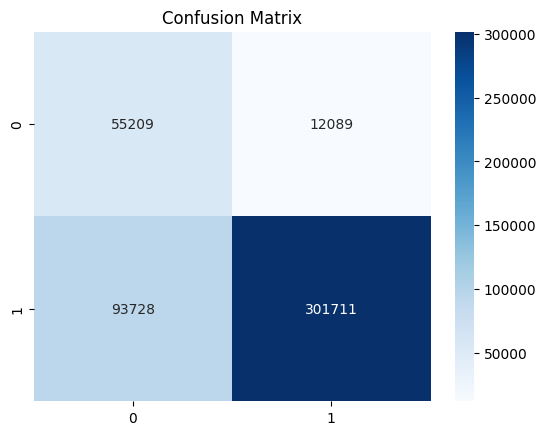

ROC-AUC: 0.14214104704551167


In [13]:
# Train Logistic Regression 

from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=500,
    class_weight='balanced',
    solver='lbfgs'
)

lr.fit(X_train_scaled, y_train)

evaluate_model(lr, X_test_scaled, y_test)

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestClassifier()

param_dist = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 20],
    'min_samples_split': [2, 5]
}

random_search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=5,
    cv=3,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train, y_train)

print("Best Parameters:", random_search.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best Parameters: {'n_estimators': 50, 'min_samples_split': 5, 'max_depth': 20}


In [14]:
best_rf = random_search.best_estimator_
y_pred = best_rf.predict(X_test)

              precision    recall  f1-score   support

      Attack       0.99      0.98      0.99     67298
      Benign       1.00      1.00      1.00    395439

    accuracy                           1.00    462737
   macro avg       1.00      0.99      0.99    462737
weighted avg       1.00      1.00      1.00    462737



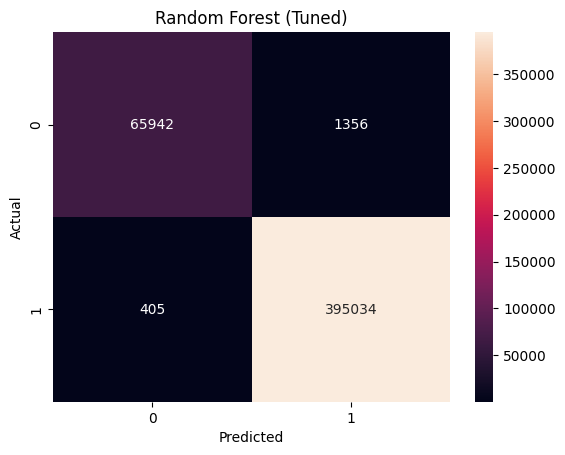

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Random Forest (Tuned)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Classification Report:
              precision    recall  f1-score   support

      Attack       0.99      0.98      0.98     67298
      Benign       1.00      1.00      1.00    395439

    accuracy                           1.00    462737
   macro avg       0.99      0.99      0.99    462737
weighted avg       1.00      1.00      1.00    462737



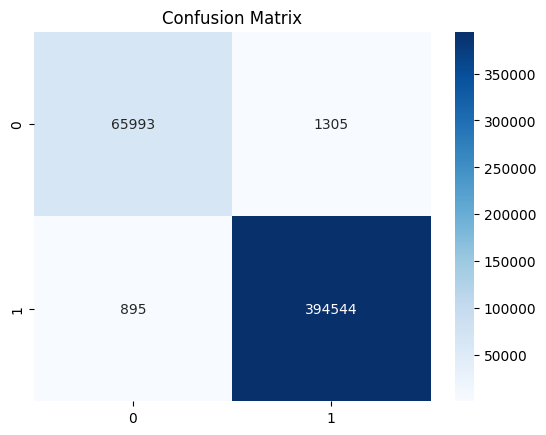

ROC-AUC: 0.003909762611462264


In [16]:
# Train Random Forest 

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train_scaled, y_train)

evaluate_model(rf, X_test_scaled, y_test)

In [13]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Convert labels to 0/1
y_train_bin = (y_train == "Attack").astype(int)
y_test_bin = (y_test == "Attack").astype(int)

xgb.fit(X_train_scaled, y_train_bin)

y_pred = xgb.predict(X_test_scaled)

print(classification_report(y_test_bin, y_pred))


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\xgboost\training.py:200: UserWarning: [23:08:10] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


              precision    recall  f1-score   support

           0       0.99      1.00      1.00    395439
           1       0.99      0.97      0.98     67298

    accuracy                           0.99    462737
   macro avg       0.99      0.98      0.99    462737
weighted avg       0.99      0.99      0.99    462737



In [17]:
import joblib
joblib.dump(rf, "models/best_model.pkl")


['models/best_model.pkl']

Random Forest performed best but showed overfitting

In [9]:
import tensorflow as tf
print(tf.__version__)
y_train_dl = (y_train == "Attack").astype(int)
y_test_dl = (y_test == "Attack").astype(int)

X_train_dl = X_train_scaled.astype("float32")
X_test_dl = X_test_scaled.astype("float32")

2.20.0


In [10]:
# Import TensorFlow & Common Utilities

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Conv1D, MaxPooling1D, Flatten, LSTM, Input
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report


In [11]:
# ANN Model

# Simple fully connected neural network
model_ann = Sequential([
    Dense(32, activation='relu', input_shape=(X_train_dl.shape[1],)),
    Dropout(0.3),
    Dense(1, activation='sigmoid')  # Binary classification
])

model_ann.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Stop training early if validation loss stops improving
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

history_ann = model_ann.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - accuracy: 0.9371 - loss: 0.1903 - val_accuracy: 0.9636 - val_loss: 0.1246
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9574 - loss: 0.1407 - val_accuracy: 0.9660 - val_loss: 0.1141
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9600 - loss: 0.1313 - val_accuracy: 0.9667 - val_loss: 0.1051
Epoch 4/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9613 - loss: 0.1248 - val_accuracy: 0.9683 - val_loss: 0.1007
Epoch 5/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9621 - loss: 0.1224 - val_accuracy: 0.9704 - val_loss: 0.0987
Epoch 6/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9631 - loss: 0.1204 - val_accuracy: 0.9712 - val_loss: 0.0974
Epoch 7/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9640 - loss: 0.1183 - val_accuracy: 0.9722 - val_loss: 0.0945
Epoch 8/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9646 - loss: 0.1170 - 

14461/14461 ━━━━━━━━━━━━━━━━━━━━ 7s 493us/step
Simple ANN Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    395439
           1       0.94      0.88      0.91     67298

    accuracy                           0.97    462737
   macro avg       0.96      0.93      0.95    462737
weighted avg       0.97      0.97      0.97    462737



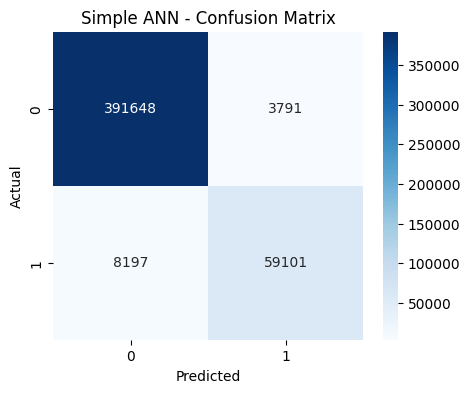

In [15]:
# Evaluate ANN
y_pred_ann = (model_ann.predict(X_test_dl) > 0.5).astype(int)

print("Simple ANN Classification Report:")
print(classification_report(y_test_dl, y_pred_ann))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_dl, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Simple ANN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()



Epoch 1/20


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2893/2893 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step - accuracy: 0.9605 - loss: 0.1222 - val_accuracy: 0.9790 - val_loss: 0.0636
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9818 - loss: 0.0541 - val_accuracy: 0.9840 - val_loss: 0.0482
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.9851 - loss: 0.0453 - val_accuracy: 0.9865 - val_loss: 0.0423
14461/14461 ━━━━━━━━━━━━━━━━━━━━ 11s 740us/step
CNN Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99    395439
           1       0.94      0.91      0.93     67298

    accuracy                           0.98    462737
   macro avg       0.96      0.95      0.96    462737
weighted avg       0.98      0.98      0.98    462737



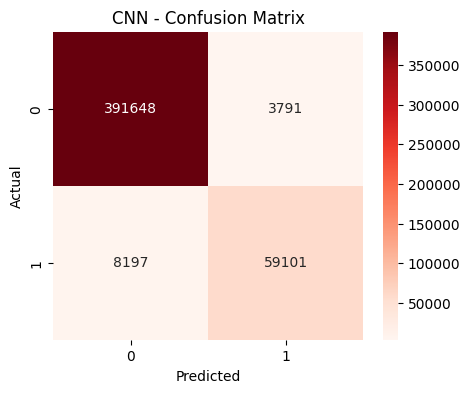

In [24]:
# CNN model
# Reshape for CNN: (samples, timesteps, features) 
X_train_cnn = np.expand_dims(X_train_dl, axis=2)
X_test_cnn = np.expand_dims(X_test_dl, axis=2)

model_cnn = Sequential([
    Conv1D(32, kernel_size=2, activation='relu', input_shape=(X_train_cnn.shape[1],1)),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_cnn = model_cnn.fit(
    X_train_cnn,
    y_train_dl,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate CNN 

y_pred_cnn = (model_cnn.predict(X_test_cnn) > 0.5).astype(int)

print("CNN Classification Report:")
print(classification_report(y_test_dl, y_pred_cnn))


# Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_dl, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds') 
plt.title("CNN - Confusion Matrix") 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Epoch 1/20


C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2893/2893 ━━━━━━━━━━━━━━━━━━━━ 16s 5ms/step - accuracy: 0.9483 - loss: 0.1435 - val_accuracy: 0.9725 - val_loss: 0.0799
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9767 - loss: 0.0699 - val_accuracy: 0.9799 - val_loss: 0.0589
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 14s 5ms/step - accuracy: 0.9841 - loss: 0.0516 - val_accuracy: 0.9867 - val_loss: 0.0460
14461/14461 ━━━━━━━━━━━━━━━━━━━━ 12s 836us/step
LSTM Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98    395439
           1       0.92      0.89      0.90     67298

    accuracy                           0.97    462737
   macro avg       0.95      0.94      0.94    462737
weighted avg       0.97      0.97      0.97    462737



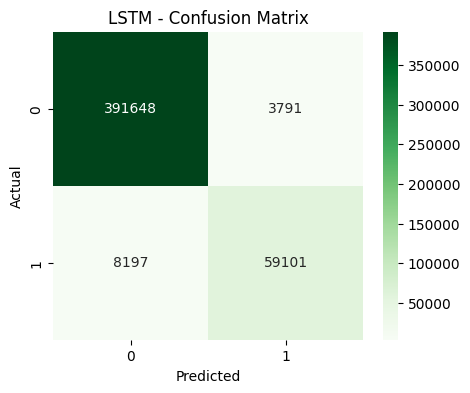

In [25]:
# LSTM Model 
model_lstm = Sequential([
    LSTM(32, input_shape=(X_train_cnn.shape[1],1)),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_lstm = model_lstm.fit(
    X_train_cnn,
    y_train_dl,
    validation_split=0.2,
    epochs=20,
    batch_size=512,
    callbacks=[early_stop],
    verbose=1
)

#Evaluate LSTM 
y_pred_lstm = (model_lstm.predict(X_test_cnn) > 0.5).astype(int)

print("LSTM Classification Report:")
print(classification_report(y_test_dl, y_pred_lstm))

# Confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_dl, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens') 
plt.title("LSTM - Confusion Matrix") 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Epoch 1/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step - loss: 0.0481 - val_loss: 0.0034
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0027 - val_loss: 0.0021
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 0.0013 - val_loss: 8.2761e-04
Epoch 4/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 4.9728e-04 - val_loss: 3.6851e-04
Epoch 5/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 2.7368e-04 - val_loss: 1.9030e-04
Epoch 6/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1.5384e-04 - val_loss: 1.6348e-04
Epoch 7/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 1.0370e-04 - val_loss: 9.2262e-05
Epoch 8/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 6.9143e-05 - val_loss: 7.5183e-05
Epoch 9/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 4.6518e-05 - val_loss: 3.1624e-05
Epoch 10/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - loss: 3.0209e-05 - val_loss: 4.4774e-05
Epoch 11/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - lo

C:\Users\KUSHAL\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


2893/2893 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.9333 - loss: 0.2162 - val_accuracy: 0.9530 - val_loss: 0.1669
Epoch 2/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9557 - loss: 0.1544 - val_accuracy: 0.9568 - val_loss: 0.1466
Epoch 3/20
2893/2893 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9575 - loss: 0.1427 - val_accuracy: 0.9589 - val_loss: 0.1384
14461/14461 ━━━━━━━━━━━━━━━━━━━━ 7s 455us/step
Autoencoder + Classifier Report:
              precision    recall  f1-score   support

           0       0.96      0.98      0.97    395439
           1       0.88      0.78      0.83     67298

    accuracy                           0.95    462737
   macro avg       0.92      0.88      0.90    462737
weighted avg       0.95      0.95      0.95    462737



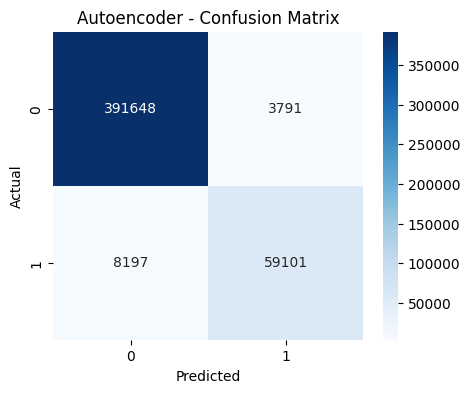

In [26]:
# Autoencoder Model 
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input

# Encoder
input_layer = Input(shape=(X_train_dl.shape[1],))
encoded = Dense(16, activation='relu')(input_layer)
encoded = Dense(8, activation='relu')(encoded)

# Decoder
decoded = Dense(16, activation='relu')(encoded)
decoded = Dense(X_train_dl.shape[1], activation='linear')(decoded)

autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train autoencoder
autoencoder.fit(
    X_train_dl,
    X_train_dl,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
    verbose=1
)

# Extract encoder
encoder = Model(input_layer, encoded)

# Transform data
X_train_encoded = encoder.predict(X_train_dl)
X_test_encoded = encoder.predict(X_test_dl)

# Train classifier on encoded features
classifier = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_encoded.shape[1],)),
    Dense(1, activation='sigmoid')
])

classifier.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

classifier.fit(
    X_train_encoded,
    y_train_dl,
    epochs=20,
    batch_size=512,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluate Autoencoder 
y_pred_auto = (classifier.predict(X_test_encoded) > 0.5).astype(int)

print("Autoencoder + Classifier Report:")
print(classification_report(y_test_dl, y_pred_auto))

 
# Confusion matrix 
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_dl, y_pred_ann)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues') 
plt.title("Autoencoder - Confusion Matrix") 
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [27]:
model_deep_ann.save("models/best_dl_model.h5")


DL models were explored but had limitations